In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS', 'subset'])
idx = np.where((tmp['subset']=='deep') & (tmp['TARGETS']=='QSO+LRG'))[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

34868
34702


In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 24255 5115 0.8258426966292135
24255


In [6]:
# Ting-Wen's quality cuts
mask = zbest['ZWARN']==0
mask &= zbest['Z']<1.4
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['DELTACHI2']>20
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 23722 533 0.9780251494537209
Quality cuts 23562 693 0.9714285714285714
23562


__Add MEDIUM and WISE masks and require NOBS>=2__

In [7]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.07830404889228419


In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [9]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [12]:
# Baseline (600/sqdeg) IR selection without the high-z extension (zfiber<21.5)
# Same as LRG_IR in v1.3

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg0_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg0_north = lrg_mask.copy()

lrg0 = lrg0_south | lrg0_north
print(np.sum(lrg0))

6117


In [13]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.35
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

########################################################################

# zfiber extension & more restrictive sliding cut, with the same 600/sqdeg density as baseline

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.09) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.19) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.05) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.15) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.45
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_sv3_lowdens_north = lrg_mask.copy()

lrg_sv3_lowdens = lrg_sv3_lowdens_south | lrg_sv3_lowdens_north
print(np.sum(lrg_sv3_lowdens))

8175
6132


In [14]:
# numbers from another notebook
area_tot = 10109.0144
n_lrg0_tot = 6252619
n_lrg_sv3_tot = 8265136
n_lrg_sv3_lowdens_tot = 6165824

area0_south = np.sum(lrg0_south)/n_lrg0_tot * area_tot
area_sv3_south = np.sum(lrg_sv3_south)/n_lrg_sv3_tot * area_tot
area_sv3_lowdens_south = np.sum(lrg_sv3_lowdens_south)/n_lrg_sv3_lowdens_tot * area_tot
print(area0_south, area_sv3_south, area_sv3_lowdens_south)

area0_north = np.sum(lrg0_north)/n_lrg0_tot * area_tot
area_sv3_north = np.sum(lrg_sv3_north)/n_lrg_sv3_tot * area_tot
area_sv3_lowdens_north = np.sum(lrg_sv3_lowdens_north)/n_lrg_sv3_lowdens_tot * area_tot
print(area0_north, area_sv3_north, area_sv3_lowdens_north)

4.292510583485096 4.324850180130127 4.33817963380077
5.597239789086781 5.673919679192212 5.715379517547046


South


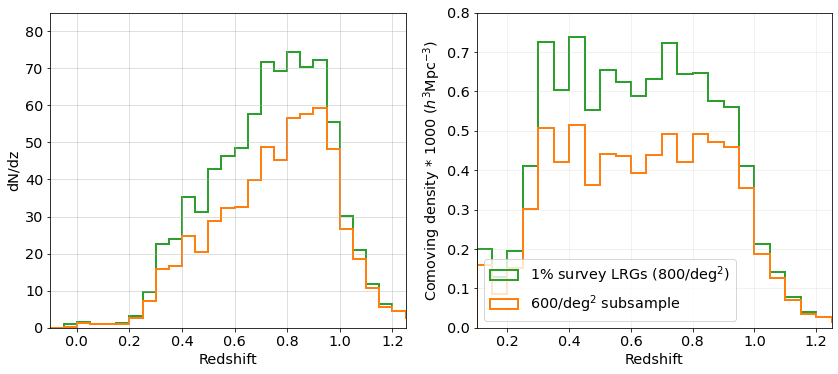

In [15]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.1, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_sv3_south], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_south)))/area_sv3_south, histtype='step', color='C2')
axes[0].hist(zbest['Z'][lrg_sv3_lowdens_south], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_lowdens_south)))/area_sv3_lowdens_south, histtype='step', color='C1')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 85)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_south], area=area_sv3_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label='1% survey LRGs (800/deg$^2$)', color='C2')
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_lowdens_south], area=area_sv3_lowdens_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label=r'600/deg$^2$ subsample', color='C1')
plt.legend(loc='lower left')
plt.show()

South


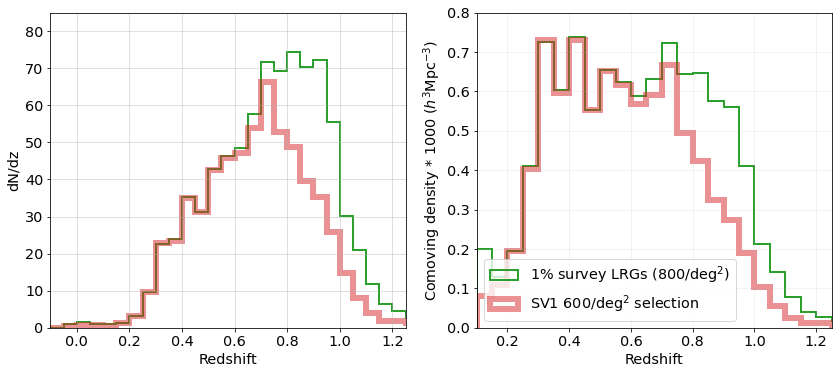

In [16]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.1, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_sv3_south], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_south)))/area_sv3_south, histtype='step', color='C2')
# axes[0].hist(zbest['Z'][lrg_sv3_lowdens_south], bins=bins, lw=2,
#              weights=np.ones(int(np.sum(lrg_sv3_lowdens_south)))/area_sv3_lowdens_south, histtype='step', color='C1')
axes[0].hist(zbest['Z'][lrg0_south], bins=bins, lw=6, alpha=0.5,
             weights=np.ones(int(np.sum(lrg0_south)))/area0_south, histtype='step', color='C3')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 85)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_south], area=area_sv3_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label='1% survey LRGs (800/deg$^2$)', color='C2')
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_lowdens_south], area=area_sv3_lowdens_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label=r'600/deg$^2$ subsample', color='C1')
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg0_south], area=area0_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=6, alpha=0.5, label=r'SV1 600/deg$^2$ selection', color='C3')
plt.legend(loc='lower left')
plt.show()

South


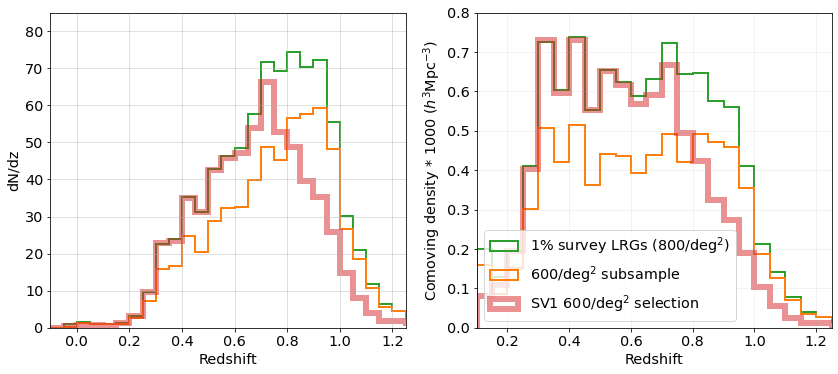

In [17]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.1, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_sv3_south], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_south)))/area_sv3_south, histtype='step', color='C2')
axes[0].hist(zbest['Z'][lrg_sv3_lowdens_south], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_lowdens_south)))/area_sv3_lowdens_south, histtype='step', color='C1')
axes[0].hist(zbest['Z'][lrg0_south], bins=bins, lw=6, alpha=0.5,
             weights=np.ones(int(np.sum(lrg0_south)))/area0_south, histtype='step', color='C3')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 85)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_south], area=area_sv3_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label='1% survey LRGs (800/deg$^2$)', color='C2')
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_lowdens_south], area=area_sv3_lowdens_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label=r'600/deg$^2$ subsample', color='C1')
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg0_south], area=area0_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=6, alpha=0.5, label=r'SV1 600/deg$^2$ selection', color='C3')
plt.legend(loc='lower left')
plt.show()

North


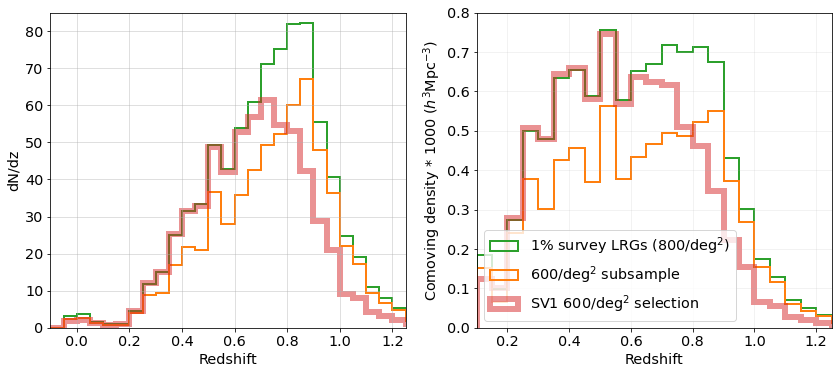

In [18]:
print('North')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.1, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_sv3_north], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_north)))/area_sv3_north, histtype='step', color='C2')
axes[0].hist(zbest['Z'][lrg_sv3_lowdens_north], bins=bins, lw=2,
             weights=np.ones(int(np.sum(lrg_sv3_lowdens_north)))/area_sv3_lowdens_north, histtype='step', color='C1')
axes[0].hist(zbest['Z'][lrg0_north], bins=bins, lw=6, alpha=0.5,
             weights=np.ones(int(np.sum(lrg0_north)))/area0_north, histtype='step', color='C3')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 85)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_north], area=area_sv3_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label='1% survey LRGs (800/deg$^2$)', color='C2')
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_lowdens_north], area=area_sv3_lowdens_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=2, label=r'600/deg$^2$ subsample', color='C1')
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg0_north], area=area0_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=6, alpha=0.5, label=r'SV1 600/deg$^2$ selection', color='C3')
plt.legend(loc='lower left')
plt.show()